# 01 — Perfil epidemiológico con SQL

**Proyecto:** BRFSS 2015 — Análisis SQL de Riesgo de Diabetes  
**Repositorio:** https://github.com/Jesusrodriguezf90/brfss2015-diabetes-sql-analysis  
**Fase:** Análisis exploratorio — perfil de la población

---

Análisis del perfil epidemiológico de la población del BRFSS 2015 mediante consultas SQL con DuckDB.
El dataset se carga directamente desde HF Hub — no se requieren datos locales.
Las queries filtran explícitamente los valores `-1` (NS/NC / Se negó) para garantizar resultados clínicamente válidos.

In [2]:
"""
Notebook: 01_eda_sql.ipynb

Objetivo:
    Analizar el perfil epidemiológico de la población del BRFSS 2015
    mediante consultas SQL con DuckDB sobre el dataset preprocesado.
    Incluye distribución por edad, IMC, sexo y estado de salud general,
    cruzados con la variable objetivo DIABETE3.

Autor:   Jesús Rodríguez
Fecha:   2026-06-11
Versión: 1.0.0
"""

'\nNotebook: 01_eda_sql.ipynb\n\nObjetivo:\n    Analizar el perfil epidemiológico de la población del BRFSS 2015\n    mediante consultas SQL con DuckDB sobre el dataset preprocesado.\n    Incluye distribución por edad, IMC, sexo y estado de salud general,\n    cruzados con la variable objetivo DIABETE3.\n\nAutor:   Jesús Rodríguez\nFecha:   2026-06-11\nVersión: 1.0.0\n'

## 0. Setup

In [3]:
# Instalación de dependencias si no están disponibles en el entorno
%pip install duckdb pandas matplotlib seaborn huggingface_hub -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Importaciones
import warnings

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Estilo global de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print(f'DuckDB {duckdb.__version__} | pandas {pd.__version__}')

DuckDB 1.5.3 | pandas 3.0.3


In [5]:
# URL pública del dataset preprocesado en HF Hub
# No requiere token — dataset público
URL_DATASET = 'hf://datasets/Jesusrodriguezf90/brfss2015-diabetes-detection/cleaned_dataset.csv'

# Carga del dataset
df = pd.read_csv(URL_DATASET)

print(f'Dataset cargado: {df.shape[0]:,} registros · {df.shape[1]} columnas')

Dataset cargado: 257,709 registros · 23 columnas


In [6]:
# Registro del DataFrame como tabla DuckDB
# Permite ejecutar SQL directamente sobre el DataFrame sin servidor
con = duckdb.connect()
con.register('brfss', df)

# Validación del esquema y distribución de la variable objetivo
print('=' * 60)
print('VALIDACIÓN DEL DATASET')
print('=' * 60)

resumen = con.execute("""
    SELECT
        COUNT(*)                                          AS total_registros,
        SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END)  AS n_diabeticos,
        SUM(CASE WHEN DIABETE3 = 3.0 THEN 1 ELSE 0 END)  AS n_no_diabeticos,
        ROUND(
            SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        )                                                 AS pct_diabeticos
    FROM brfss
""").df()

print(f"  Total registros  : {resumen['total_registros'][0]:,}")
print(f"  Diabéticos       : {resumen['n_diabeticos'][0]:,} ({resumen['pct_diabeticos'][0]}%)")
print(f"  No diabéticos    : {resumen['n_no_diabeticos'][0]:,}")
print('=' * 60)
print('[OK] Dataset registrado en DuckDB — listo para análisis SQL')

VALIDACIÓN DEL DATASET
  Total registros  : 257,709
  Diabéticos       : 28,391.0 (11.0%)
  No diabéticos    : 229,318.0
[OK] Dataset registrado en DuckDB — listo para análisis SQL


## 1. Perfil de la población

Análisis de la distribución de la población por las variables demográficas y clínicas principales,
cruzadas con la variable objetivo `DIABETE3`.

Los valores `-1.0` (NS/NC / Se negó) se excluyen de todas las queries para garantizar
resultados clínicamente válidos. Las etiquetas de cada variable siguen la codificación
oficial del codebook CDC BRFSS 2015.

### 1.1 Distribución por grupo de edad y prevalencia de diabetes

In [7]:
# Prevalencia de diabetes por grupo de edad (_AGEG5YR)
# Se filtran valores -1 (NS/NC) y se decodifican los grupos de 5 años del codebook CDC
resultado_edad = con.execute("""
    SELECT
        CASE _AGEG5YR
            WHEN 1  THEN '18-24'
            WHEN 2  THEN '25-29'
            WHEN 3  THEN '30-34'
            WHEN 4  THEN '35-39'
            WHEN 5  THEN '40-44'
            WHEN 6  THEN '45-49'
            WHEN 7  THEN '50-54'
            WHEN 8  THEN '55-59'
            WHEN 9  THEN '60-64'
            WHEN 10 THEN '65-69'
            WHEN 11 THEN '70-74'
            WHEN 12 THEN '75-79'
            WHEN 13 THEN '80+'
        END                                                          AS grupo_edad,
        _AGEG5YR                                                     AS orden,
        COUNT(*)                                                     AS n_total,
        SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END)             AS n_diabeticos,
        ROUND(
            SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        )                                                            AS prevalencia_pct
    FROM brfss
    WHERE _AGEG5YR != -1.0
    GROUP BY _AGEG5YR
    ORDER BY _AGEG5YR
""").df()

print('-' * 55)
print(f"{'Grupo edad':<12} {'N total':>10} {'Diabéticos':>12} {'Prevalencia':>12}")
print('-' * 55)
for _, row in resultado_edad.iterrows():
    print(f"{row['grupo_edad']:<12} {int(row['n_total']):>10,} {int(row['n_diabeticos']):>12,} {row['prevalencia_pct']:>11.1f}%")
print('-' * 55)

-------------------------------------------------------
Grupo edad      N total   Diabéticos  Prevalencia
-------------------------------------------------------
18-24            15,713          136         0.9%
25-29            12,199          153         1.3%
30-34            13,853          291         2.1%
35-39            14,857          543         3.7%
40-44            15,908          869         5.5%
45-49            18,586        1,353         7.3%
50-54            23,905        2,310         9.7%
55-59            27,598        3,201        11.6%
60-64            29,882        4,437        14.8%
65-69            29,876        5,222        17.5%
70-74            22,008        4,152        18.9%
75-79            14,944        2,839        19.0%
80+              16,909        2,744        16.2%
-------------------------------------------------------


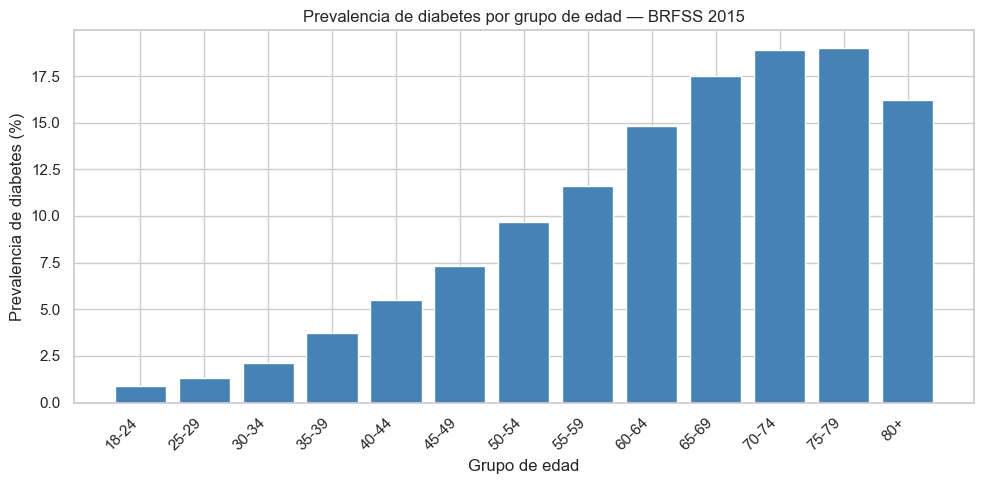

In [8]:
# Visualización de la prevalencia por grupo de edad
fig, ax = plt.subplots()
ax.bar(resultado_edad['grupo_edad'], resultado_edad['prevalencia_pct'], color='steelblue')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Prevalencia de diabetes (%)')
ax.set_title('Prevalencia de diabetes por grupo de edad — BRFSS 2015')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.2 Prevalencia de diabetes por categoría de IMC

In [9]:
# Prevalencia de diabetes por categoría de IMC (_BMI5CAT)
# _BMI5CAT no tiene valores -1 en el dataset preprocesado
resultado_bmi = con.execute("""
    SELECT
        CASE _BMI5CAT
            WHEN 1 THEN 'Bajo peso'
            WHEN 2 THEN 'Normopeso'
            WHEN 3 THEN 'Sobrepeso'
            WHEN 4 THEN 'Obesidad'
        END                                                          AS categoria_imc,
        _BMI5CAT                                                     AS orden,
        COUNT(*)                                                     AS n_total,
        SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END)             AS n_diabeticos,
        ROUND(
            SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        )                                                            AS prevalencia_pct
    FROM brfss
    GROUP BY _BMI5CAT
    ORDER BY _BMI5CAT
""").df()

print('-' * 55)
print(f"{'Categoría IMC':<15} {'N total':>10} {'Diabéticos':>12} {'Prevalencia':>12}")
print('-' * 55)
for _, row in resultado_bmi.iterrows():
    print(f"{row['categoria_imc']:<15} {int(row['n_total']):>10,} {int(row['n_diabeticos']):>12,} {row['prevalencia_pct']:>11.1f}%")
print('-' * 55)

-------------------------------------------------------
Categoría IMC      N total   Diabéticos  Prevalencia
-------------------------------------------------------
Bajo peso            3,861          141         3.7%
Normopeso           90,209        4,269         4.7%
Sobrepeso           96,253        9,963        10.4%
Obesidad            67,386       14,018        20.8%
-------------------------------------------------------


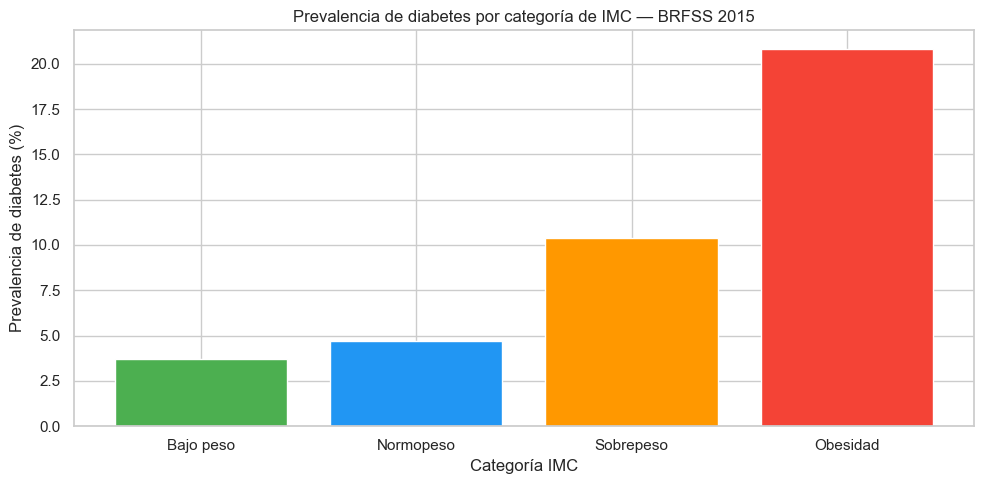

In [10]:
# Visualización de la prevalencia por categoría de IMC
colores = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
fig, ax = plt.subplots()
ax.bar(resultado_bmi['categoria_imc'], resultado_bmi['prevalencia_pct'], color=colores)
ax.set_xlabel('Categoría IMC')
ax.set_ylabel('Prevalencia de diabetes (%)')
ax.set_title('Prevalencia de diabetes por categoría de IMC — BRFSS 2015')
plt.tight_layout()
plt.show()

### 1.3 Distribución por sexo y estado de salud general

In [12]:
# Distribución por sexo y estado de salud general (GENHLTH)
# cruzada con clase diabética — se filtran valores -1 en GENHLTH
# HAVING elimina combinaciones con menos de 100 registros (estadísticamente inestables)
resultado_sexo_salud = con.execute("""
    SELECT
        CASE SEX
            WHEN 1 THEN 'Masculino'
            WHEN 2 THEN 'Femenino'
        END                                                          AS sexo,
        CASE GENHLTH
            WHEN 1 THEN 'Excelente'
            WHEN 2 THEN 'Muy buena'
            WHEN 3 THEN 'Buena'
            WHEN 4 THEN 'Regular'
            WHEN 5 THEN 'Mala'
        END                                                          AS salud_general,
        GENHLTH                                                      AS orden_salud,
        COUNT(*)                                                     AS n_total,
        ROUND(
            SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        )                                                            AS prevalencia_pct
    FROM brfss
    WHERE GENHLTH != -1.0
    GROUP BY SEX, GENHLTH
    HAVING COUNT(*) >= 100
    ORDER BY SEX, GENHLTH
""").df()

print('-' * 60)
print(f"{'Sexo':<12} {'Salud general':<12} {'N total':>10} {'Prevalencia':>12}")
print('-' * 60)
for _, row in resultado_sexo_salud.iterrows():
    print(f"{row['sexo']:<12} {row['salud_general']:<12} {int(row['n_total']):>10,} {row['prevalencia_pct']:>11.1f}%")
print('-' * 60)

------------------------------------------------------------
Sexo         Salud general    N total  Prevalencia
------------------------------------------------------------
Masculino    Excelente        23,672         2.9%
Masculino    Muy buena        42,952         7.3%
Masculino    Buena            34,605        16.7%
Masculino    Regular          11,432        29.1%
Masculino    Mala              3,374        36.5%
Femenino     Excelente        30,009         1.5%
Femenino     Muy buena        53,520         5.3%
Femenino     Buena            39,634        14.4%
Femenino     Regular          14,004        27.0%
Femenino     Mala              4,069        34.0%
------------------------------------------------------------


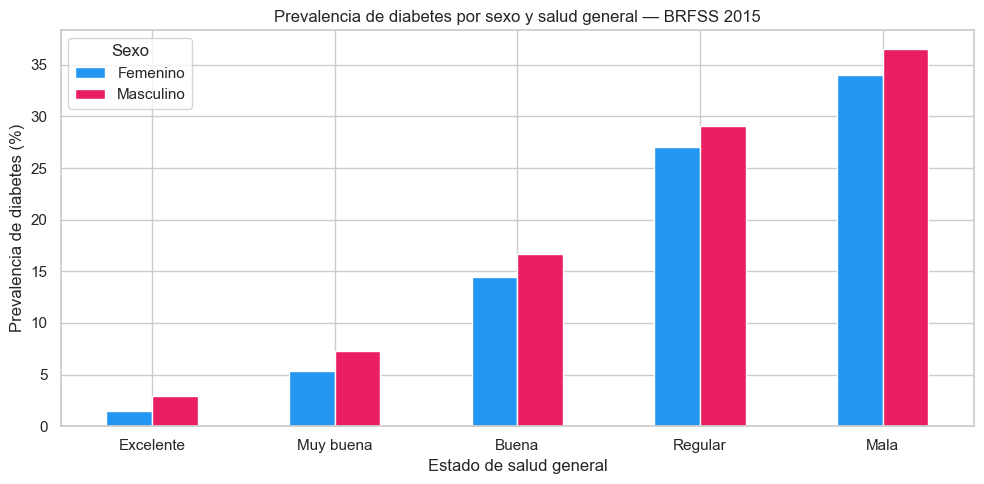

In [13]:
# Visualización comparativa hombre vs mujer por nivel de salud general
pivot = resultado_sexo_salud.pivot(index='salud_general', columns='sexo', values='prevalencia_pct')

# Reordenar por severidad clínica
orden = ['Excelente', 'Muy buena', 'Buena', 'Regular', 'Mala']
pivot = pivot.reindex(orden)

pivot.plot(kind='bar', ax=plt.subplots()[1], color=['#2196F3', '#E91E63'])
plt.xlabel('Estado de salud general')
plt.ylabel('Prevalencia de diabetes (%)')
plt.title('Prevalencia de diabetes por sexo y salud general — BRFSS 2015')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

## 2. Resumen de la ejecución

In [14]:
# Resumen de los hallazgos principales del notebook
edad_max = resultado_edad.loc[resultado_edad['prevalencia_pct'].idxmax()]
bmi_max  = resultado_bmi.loc[resultado_bmi['prevalencia_pct'].idxmax()]
bmi_min  = resultado_bmi.loc[resultado_bmi['prevalencia_pct'].idxmin()]

print('=' * 60)
print('RESUMEN — PERFIL EPIDEMIOLÓGICO')
print('=' * 60)
print(f"  Dataset             : {df.shape[0]:,} registros · {df.shape[1]} columnas")
print(f"  Prevalencia global  : {resumen['pct_diabeticos'][0]}% diabéticos")
print(f"  Grupo edad mayor    : {edad_max['grupo_edad']} años ({edad_max['prevalencia_pct']}%)")
print(f"  IMC mayor prev.     : {bmi_max['categoria_imc']} ({bmi_max['prevalencia_pct']}%)")
print(f"  IMC menor prev.     : {bmi_min['categoria_imc']} ({bmi_min['prevalencia_pct']}%)")
print('=' * 60)
print('Siguiente paso: 02_risk_factors_sql.ipynb')

RESUMEN — PERFIL EPIDEMIOLÓGICO
  Dataset             : 257,709 registros · 23 columnas
  Prevalencia global  : 11.0% diabéticos
  Grupo edad mayor    : 75-79 años (19.0%)
  IMC mayor prev.     : Obesidad (20.8%)
  IMC menor prev.     : Bajo peso (3.7%)
Siguiente paso: 02_risk_factors_sql.ipynb
